2025-03-19 23:59:12.834 | INFO     | __main__:linear_regression_numpy:6 - [[1.74908024e+03 4.00000000e+00]
 [2.90142861e+03 5.00000000e+00]
 [2.46398788e+03 4.00000000e+00]
 [2.19731697e+03 2.00000000e+00]
 [1.31203728e+03 5.00000000e+00]
 [1.31198904e+03 2.00000000e+00]
 [1.11616722e+03 5.00000000e+00]
 [2.73235229e+03 5.00000000e+00]
 [2.20223002e+03 3.00000000e+00]
 [2.41614516e+03 2.00000000e+00]
 [1.04116899e+03 4.00000000e+00]
 [2.93981970e+03 4.00000000e+00]
 [2.66488528e+03 2.00000000e+00]
 [1.42467822e+03 4.00000000e+00]
 [1.36364993e+03 4.00000000e+00]
 [1.36680902e+03 2.00000000e+00]
 [1.60848449e+03 5.00000000e+00]
 [2.04951286e+03 2.00000000e+00]
 [1.86389004e+03 5.00000000e+00]
 [1.58245828e+03 4.00000000e+00]
 [2.22370579e+03 4.00000000e+00]
 [1.27898772e+03 4.00000000e+00]
 [1.58428930e+03 3.00000000e+00]
 [1.73272369e+03 5.00000000e+00]
 [1.91213997e+03 3.00000000e+00]
 [2.57035192e+03 3.00000000e+00]
 [1.39934756e+03 2.00000000e+00]
 [2.02846888e+03 3.00000000e+00]
 [

NumPy Implementation Results:
Estimated weights: [  149.35626335 19546.79892549]
Estimated intercept: 53260.80673283887
Training MSE: 88490898.16
Test MSE: 132674918.61


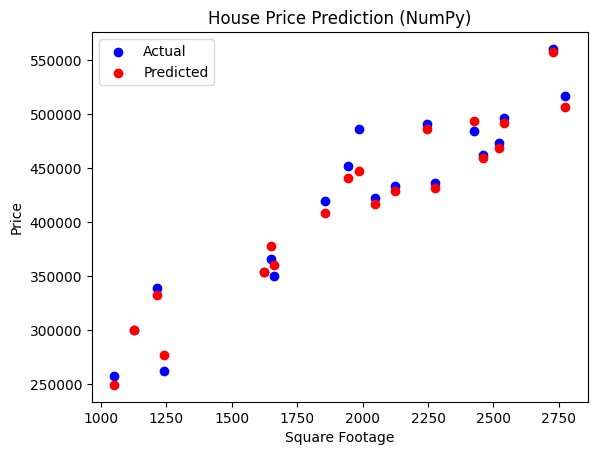

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from loguru import logger

def linear_regression_numpy(X, y):
    logger.info(X)
    """Simple linear regression using NumPy"""
    X = np.hstack((np.ones((X.shape[0], 1)), X))  # Add intercept term
    logger.info(f"X: {X.shape}")
    logger.info(X)
    coefficients = np.linalg.pinv(X.T @ X) @ X.T @ y
    return coefficients[1:], coefficients[0]  # weights, intercept

def predict_numpy(X, weights, intercept):
    """Make predictions using NumPy"""
    return X @ weights + intercept

# Generate synthetic house price data
np.random.seed(42)
n_samples = 100

# Features: square footage (1000-3000 sq ft), bedrooms (2-5)
square_footage = np.random.uniform(1000, 3000, n_samples)
bedrooms = np.random.randint(2, 6, n_samples)
X = np.column_stack((square_footage, bedrooms))

# True relationship: price = 150 * sq_ft + 20000 * beds + base_price + noise
true_weights = np.array([150, 20000])
true_intercept = 50000
y = X @ true_weights + true_intercept + np.random.normal(0, 10000, n_samples)

# Split data into train and test (80-20 split)
train_idx = int(n_samples * 0.8)
X_train, X_test = X[:train_idx], X[train_idx:]
y_train, y_test = y[:train_idx], y[train_idx:]

# Fit model
weights, intercept = linear_regression_numpy(X_train, y_train)

# Make predictions
y_pred_train = predict_numpy(X_train, weights, intercept)
y_pred_test = predict_numpy(X_test, weights, intercept)

# Calculate MSE
mse_train = np.mean((y_train - y_pred_train) ** 2)
mse_test = np.mean((y_test - y_pred_test) ** 2)

# Print results
print("NumPy Implementation Results:")
print(f"Estimated weights: {weights}")
print(f"Estimated intercept: {intercept}")
print(f"Training MSE: {mse_train:.2f}")
print(f"Test MSE: {mse_test:.2f}")

# Visualize predictions vs actual (for square footage only)
plt.scatter(X_test[:, 0], y_test, color='blue', label='Actual')
plt.scatter(X_test[:, 0], y_pred_test, color='red', label='Predicted')
plt.xlabel('Square Footage')
plt.ylabel('Price')
plt.title('House Price Prediction (NumPy)')
plt.legend()
plt.show()